In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats


In [25]:
ticker = ["SBIN.NS", "KOTAKBANK.NS", "AXISBANK.NS", "ICICIBANK.NS", "HDFCBANK.NS"]
data = yf.download(ticker,start = "2019-1-1",end="2024-1-1")
prices = data["Close"]

#log return
log_return = np.log(prices/prices.shift(1))
log_return = log_return.dropna()

print(log_return.shape)
print(log_return.head())

[*********************100%***********************]  5 of 5 completed


(1234, 5)
Ticker      AXISBANK.NS  HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS   SBIN.NS
Date                                                                      
2019-01-02    -0.011625    -0.009166      0.002334     -0.007908 -0.019209
2019-01-03    -0.019707    -0.007877     -0.003709     -0.004322 -0.009573
2019-01-04     0.018981     0.002672      0.005354      0.010229  0.022252
2019-01-07     0.028402     0.001510      0.006822     -0.001082 -0.004546
2019-01-08     0.020880    -0.008358      0.033298     -0.014300  0.029922


In [26]:
#historical VaR
confidence_interval = 0.95

hist_var = log_return.quantile(1-confidence_interval)

print("historical VaR at 95%")
print(hist_var.round(4))


historical VaR at 95%
Ticker
AXISBANK.NS    -0.0317
HDFCBANK.NS    -0.0241
ICICIBANK.NS   -0.0277
KOTAKBANK.NS   -0.0271
SBIN.NS        -0.0351
Name: 0.050000000000000044, dtype: float64


In [27]:
#parametric VaR
#formula: parametirc var = mean - z score *stddev
mean_return = log_return.mean()
std_return = log_return.std()

z_score = stats.norm.ppf(1-confidence_interval)

parametric_VaR = mean_return + z_score*std_return

print("parametric VaR at 95%")
print(parametric_VaR.round(4))

parametric VaR at 95%
Ticker
AXISBANK.NS    -0.0384
HDFCBANK.NS    -0.0275
ICICIBANK.NS   -0.0334
KOTAKBANK.NS   -0.0299
SBIN.NS        -0.0347
dtype: float64


In [28]:
#cvar 
cvar = log_return[log_return<= hist_var].mean()
print("cvar at 5% worst")
print(cvar.round(4))

cvar at 5% worst
Ticker
AXISBANK.NS    -0.0544
HDFCBANK.NS    -0.0388
ICICIBANK.NS   -0.0496
KOTAKBANK.NS   -0.0426
SBIN.NS        -0.0513
dtype: float64


In [29]:
#maximum drawdown 
def max_drawdown(returns):
    cumulative = (1+ returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = cumulative - rolling_max/rolling_max
    return drawdown.min()

mdd = log_return.apply(max_drawdown)
print("maximum drawdown:")
print(mdd.round(4))

maximum drawdown:
Ticker
AXISBANK.NS    -0.5767
HDFCBANK.NS    -0.3115
ICICIBANK.NS   -0.3024
KOTAKBANK.NS   -0.1875
SBIN.NS        -0.5582
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

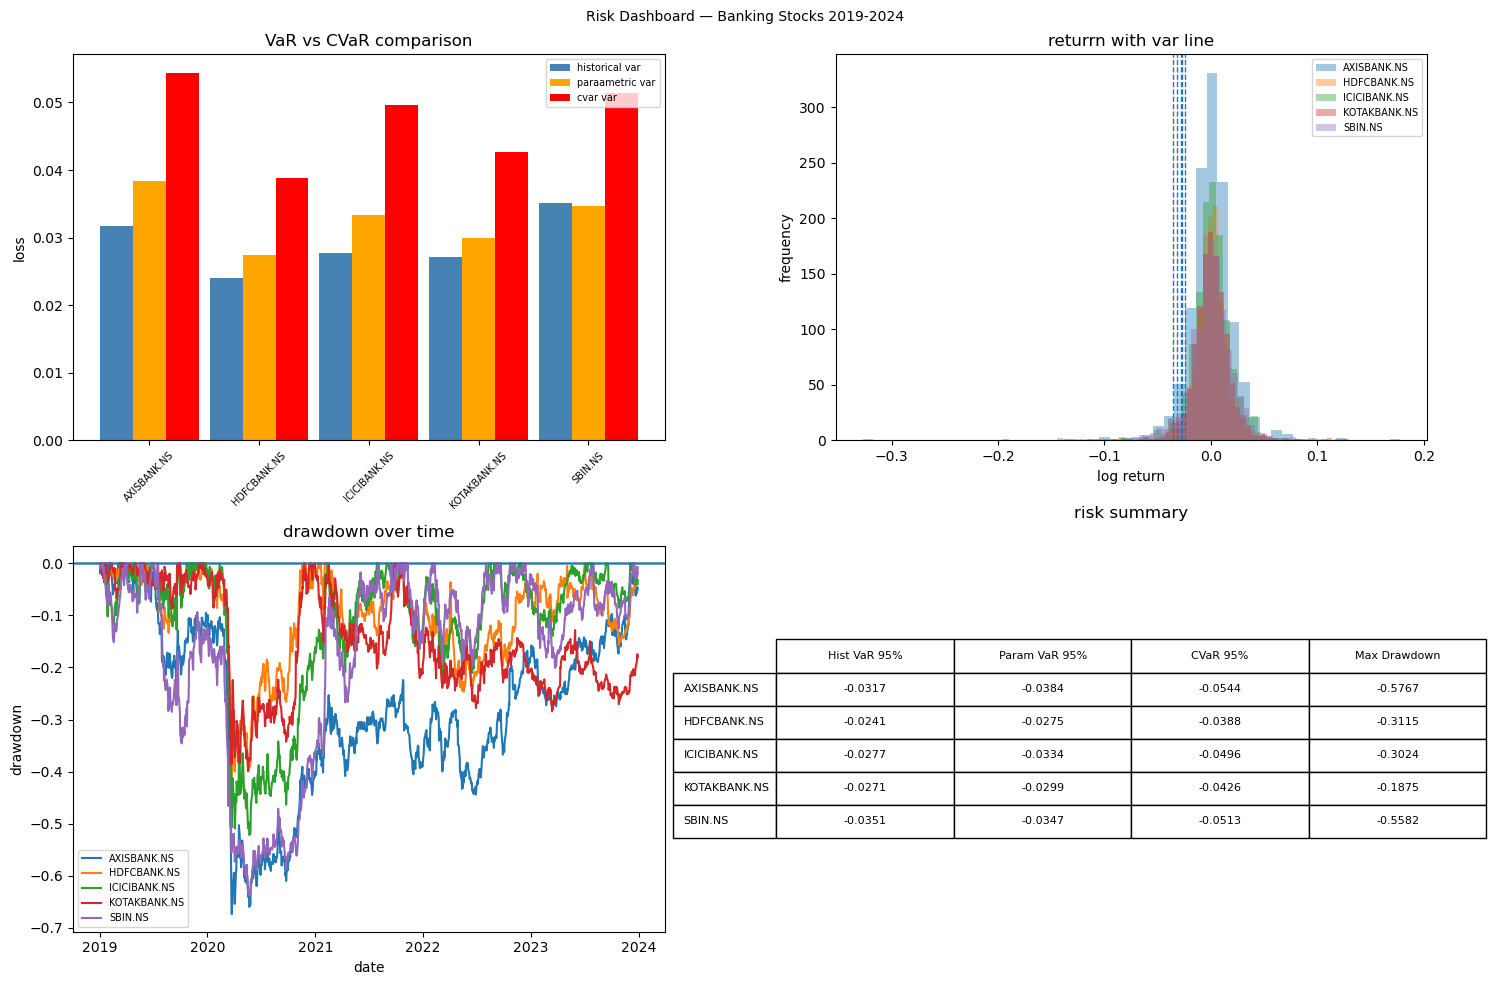

In [47]:
fig,axes = plt.subplots(2,2, figsize=(15,10))
fig.suptitle("Risk Dashboard — Banking Stocks 2019-2024",fontsize = 10)

x = range(len(log_return.columns))
width = 0.3

axes[0,0].bar([i - width for i in x],
              hist_var * -1,
              width = width,
              label='historical var',
              color='steelblue')
axes[0,0].bar([i  for i in x],
              parametric_VaR *-1,
              width=width,
              label='paraametric var',
              color='orange')

axes[0,0].bar([i + width for i in x],
              cvar *-1,
              width=width,
              label='cvar var',
              color='red')

axes[0,0].set_xticks(list(x))
axes[0,0].set_xticklabels(log_return.columns,rotation = 45,fontsize=7)
axes[0,0].set_title("VaR vs CVaR comparison")
axes[0,0].set_ylabel("loss")
axes[0,0].legend(fontsize=7)

for ticker in log_return.columns:
    axes[0,1].hist(log_return[ticker],bins = 50,alpha = 0.4,label = ticker)
    axes[0,1].axvline(x=float(hist_var[ticker]),linestyle="--",linewidth=1)
    axes[0,1].set_title("returrn with var line")
    axes[0,1].set_xlabel("log return")
    axes[0,1].set_ylabel("frequency")
    axes[0,1].legend(fontsize = 7)

for ticker in log_return.columns:
    cumulative = (1+ log_return[ticker]).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max)/rolling_max
    axes[1,0].plot(drawdown.index,drawdown,label=ticker)
    axes[1,0].set_title("drawdown over time")
    axes[1,0].set_xlabel("date")
    axes[1,0].set_ylabel("drawdown")
    axes[1,0].legend(fontsize=7)
    axes[1,0].axhline(y=0,linewidth=1)

risk_summary = pd.DataFrame({
    'Hist VaR 95%': hist_var.round(4),
    'Param VaR 95%': parametric_VaR.round(4),
    'CVaR 95%': cvar.round(4),
    'Max Drawdown': mdd.round(4)
})
axes[1,1].axis("off")
table = axes[1,1].table(
    cellText=risk_summary.values,
    rowLabels=risk_summary.index,
    colLabels=risk_summary.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2,1.8)

axes[1,1].set_title("risk summary",pad =20)

plt.tight_layout()
plt.show
